<a href="https://colab.research.google.com/github/Sameer248-r/Machine-learning-practice/blob/main/Logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TeasrCase :-** Build a predective model to predict weather a student get admission in college based on Given below data

In [10]:
import pandas as pd

candidates = {'gmat': [780,750,690,710,680,730,690,720,740,690,610,690,710,680,770,610,580,650,540,590,620,600,550,550,570,670,660,580,650,660,640,620,660,660,680,650,670,580,590,690],

              'gpa': [4,3.9,3.3,3.7,3.9,3.7,2.3,3.3,3.3,1.7,2.7,3.7,3.7,3.3,3.3,3,2.7,3.7,2.7,2.3,3.3,2,2.3,2.7,3,3.3,3.7,2.3,3.7,3.3,3,2.7,4,3.3,3.3,2.3,2.7,3.3,1.7,3.7],

              'work_experience': [3,4,3,5,4,6,1,4,5,1,3,5,6,4,3,1,4,6,2,3,2,1,4,1,2,6,4,2,6,5,1,2,4,6,5,1,2,1,4,5],

              'admitted': [1,1,0,1,0,1,0,1,1,0,0,1,1,0,1,0,0,1,0,0,1,0,0,0,0,1,1,0,1,1,0,0,1,1,1,0,0,0,0,1]

              }

In [11]:
candidates

{'gmat': [780,
  750,
  690,
  710,
  680,
  730,
  690,
  720,
  740,
  690,
  610,
  690,
  710,
  680,
  770,
  610,
  580,
  650,
  540,
  590,
  620,
  600,
  550,
  550,
  570,
  670,
  660,
  580,
  650,
  660,
  640,
  620,
  660,
  660,
  680,
  650,
  670,
  580,
  590,
  690],
 'gpa': [4,
  3.9,
  3.3,
  3.7,
  3.9,
  3.7,
  2.3,
  3.3,
  3.3,
  1.7,
  2.7,
  3.7,
  3.7,
  3.3,
  3.3,
  3,
  2.7,
  3.7,
  2.7,
  2.3,
  3.3,
  2,
  2.3,
  2.7,
  3,
  3.3,
  3.7,
  2.3,
  3.7,
  3.3,
  3,
  2.7,
  4,
  3.3,
  3.3,
  2.3,
  2.7,
  3.3,
  1.7,
  3.7],
 'work_experience': [3,
  4,
  3,
  5,
  4,
  6,
  1,
  4,
  5,
  1,
  3,
  5,
  6,
  4,
  3,
  1,
  4,
  6,
  2,
  3,
  2,
  1,
  4,
  1,
  2,
  6,
  4,
  2,
  6,
  5,
  1,
  2,
  4,
  6,
  5,
  1,
  2,
  1,
  4,
  5],
 'admitted': [1,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  1,
  0,
  0,
  1,
  1,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  1,
  1,
  0,
  0,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  1]}

In [12]:
#convert the data into dataframes
df = pd.DataFrame(candidates,columns=['gmat','gpa','work_experience','admitted'])
print(df)

    gmat  gpa  work_experience  admitted
0    780  4.0                3         1
1    750  3.9                4         1
2    690  3.3                3         0
3    710  3.7                5         1
4    680  3.9                4         0
5    730  3.7                6         1
6    690  2.3                1         0
7    720  3.3                4         1
8    740  3.3                5         1
9    690  1.7                1         0
10   610  2.7                3         0
11   690  3.7                5         1
12   710  3.7                6         1
13   680  3.3                4         0
14   770  3.3                3         1
15   610  3.0                1         0
16   580  2.7                4         0
17   650  3.7                6         1
18   540  2.7                2         0
19   590  2.3                3         0
20   620  3.3                2         1
21   600  2.0                1         0
22   550  2.3                4         0
23   550  2.7   

In [13]:
# check the data types
df.dtypes

,0
gmat,int64
gpa,float64
work_experience,int64
admitted,int64


In [14]:
#get the descriptive stast sof data
df.describe()

,gmat,gpa,work_experience,admitted
count,40.000000,40.000000,40.000000,40.000000
mean,654.000000,3.095000,3.425000,0.475000
std,61.427464,0.631218,1.737778,0.505736
min,540.000000,1.700000,1.000000,0.000000
25%,607.500000,2.700000,2.000000,0.000000
50%,660.000000,3.300000,4.000000,0.000000
75%,690.000000,3.700000,5.000000,1.000000
max,780.000000,4.000000,6.000000,1.000000


**find the presense of outliers in column gmat,gpa and work_experience**

In [15]:
iqr1 = df['gmat'].quantile(0.75) - df['gmat'].quantile(0.25)
print(iqr1)

82.5


In [16]:
UL = 690 + 1.5*(iqr1)
print(UL)

813.75


In [17]:
LL = 607.50 - 1.5*(iqr1)
print(LL)

483.75


In [18]:
df.describe()
# in column gmat minimum value is 540.00
# and maximum value is 780.00
#UL = 813.75
# LL = 483.75
# min < LL -- outlier
# max > UL -- outlier
# si in case of gmat column no ouliers predent

,gmat,gpa,work_experience,admitted
count,40.000000,40.000000,40.000000,40.000000
mean,654.000000,3.095000,3.425000,0.475000
std,61.427464,0.631218,1.737778,0.505736
min,540.000000,1.700000,1.000000,0.000000
25%,607.500000,2.700000,2.000000,0.000000
50%,660.000000,3.300000,4.000000,0.000000
75%,690.000000,3.700000,5.000000,1.000000
max,780.000000,4.000000,6.000000,1.000000


**gpa**

In [19]:
iqr2 = df['gpa'].quantile(0.75) - df['gpa'].quantile(0.25)
print(iqr2)


1.0


In [20]:
# get the descriptive stats of data
df.describe()

,gmat,gpa,work_experience,admitted
count,40.000000,40.000000,40.000000,40.000000
mean,654.000000,3.095000,3.425000,0.475000
std,61.427464,0.631218,1.737778,0.505736
min,540.000000,1.700000,1.000000,0.000000
25%,607.500000,2.700000,2.000000,0.000000
50%,660.000000,3.300000,4.000000,0.000000
75%,690.000000,3.700000,5.000000,1.000000
max,780.000000,4.000000,6.000000,1.000000


In [21]:
UL = 3.70 + 1.5*(iqr2)
print(UL)

5.2


In [22]:
LL = 2.70 - 1.5*(iqr2)
print(LL)

1.2000000000000002


In [23]:
df.describe()
# in gpa column minimum value is 1.70
# and maximum value is 4.0
# UL = 5.2
# LL = 1.20

#min < LL -- outlier
# 1.70 < 1.20 -- so no outlier
print(1.70>1.20)
# max > UL -- outlier
# 4.0 < 5.2 -- so no outlier

# so in case os gpa column there is no outliers are present

True


**work ecperience**

In [24]:
iqr3 = df['work_experience'].quantile(0.75) - df['work_experience'].quantile(0.25)
print(iqr3)


3.0


In [25]:
df.describe()

,gmat,gpa,work_experience,admitted
count,40.000000,40.000000,40.000000,40.000000
mean,654.000000,3.095000,3.425000,0.475000
std,61.427464,0.631218,1.737778,0.505736
min,540.000000,1.700000,1.000000,0.000000
25%,607.500000,2.700000,2.000000,0.000000
50%,660.000000,3.300000,4.000000,0.000000
75%,690.000000,3.700000,5.000000,1.000000
max,780.000000,4.000000,6.000000,1.000000


In [26]:
UL = 5 + 1.5*(iqr3)
print(UL)

9.5


In [27]:
LL = 2 - 1.5*(iqr3)
print(LL)

-2.5


In [28]:
df.describe()
# min = 2.0#
# max = 5.0
# UL = 9.5
# LL = -2.5

# min < LL -- outlier
# 2.0 > -2.5 -- so no outlier

# max > UL -- outlier
# 5.0 < 9.5 -- so no outlier

# so in work_experience column max and min value present in the range of UL and LL

,gmat,gpa,work_experience,admitted
count,40.000000,40.000000,40.000000,40.000000
mean,654.000000,3.095000,3.425000,0.475000
std,61.427464,0.631218,1.737778,0.505736
min,540.000000,1.700000,1.000000,0.000000
25%,607.500000,2.700000,2.000000,0.000000
50%,660.000000,3.300000,4.000000,0.000000
75%,690.000000,3.700000,5.000000,1.000000
max,780.000000,4.000000,6.000000,1.000000


In [29]:
df.isnull().sum()

,0
gmat,0
gpa,0
work_experience,0
admitted,0


In [30]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [31]:
df.drop_duplicates()
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


**EDA**

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

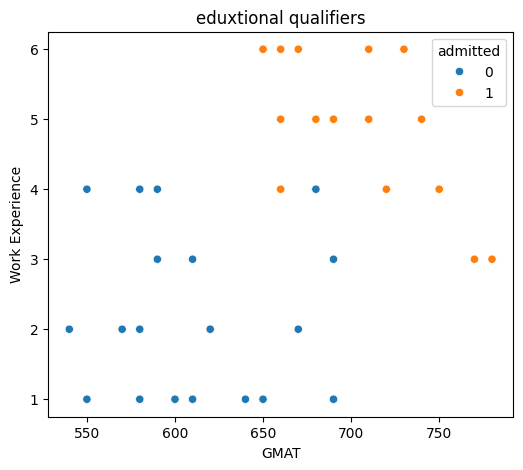

In [33]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='gmat',y='work_experience',hue='admitted',data=df)
plt.title('eduxtional qualifiers')
plt.xlabel('GMAT')
plt.ylabel('Work Experience')
plt.show()

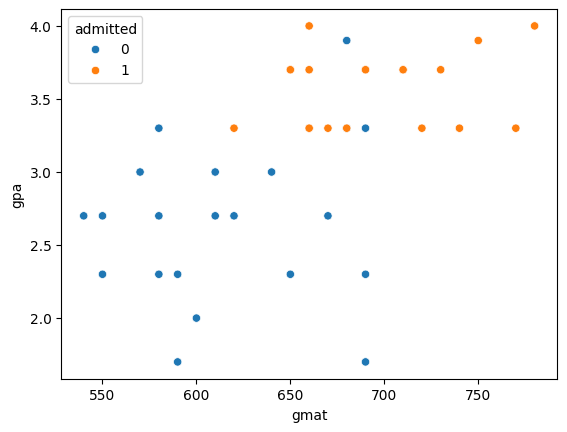

In [34]:
#draw a scatter plot with respective gmat and gpa
sns.scatterplot(x='gmat',y='gpa',data=df,hue="admitted")
plt.show()

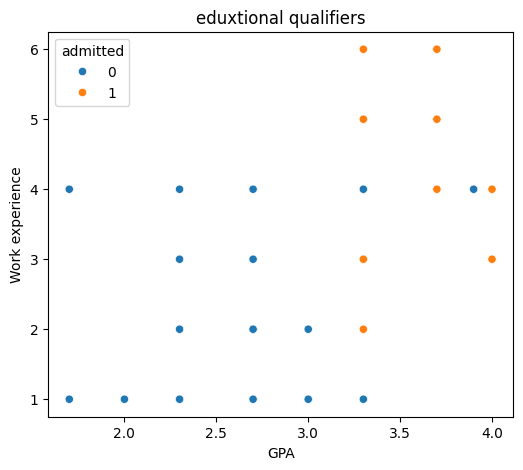

In [35]:
#draw a scatter plot with respective gpa and work experience
plt.figure(figsize=(6,5))
sns.scatterplot(x='gpa',y='work_experience',hue='admitted',data=df)
plt.title('eduxtional qualifiers')
plt.xlabel('GPA')
plt.ylabel('Work experience')
plt.show()

**Data  Jar** -->  clean.encode,split,scale
--> slicing is not mandatory in logistic regression
Q) do we need to encoding in this data?
--> no need to encode the data all the columns is numerical value

In [36]:
#before spliting the data define feature and target variable?
x = df[['gmat','gpa','work_experience']].values
y = df['admitted'].values

**split data**

In [53]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=345)

**Slicing is not mandatory**


**2.task jar:- supervised learning tak--> labelled data we know the target variable**

**3. Model Jar** --> mathematical representation o logistic regression
y = 1/(1+e^-mx-c)

y --> y is known as predicted probablity bcz it takes values between 0 and 1

m & c --> is known as parameters
x --> is feature

**import the logistic regression**

In [54]:
from sklearn.linear_model import LogisticRegression
#initialize the log reg
Logistic_regression = LogisticRegression()
#fit the model on traning data
Logistic_regression.fit(x_train,y_train) # here all the magic is happens
# find the best parameters by using the gradient descent(5th learning jar)
# predict the data on X_test data
y_pred = Logistic_regression.predict(x_test)
y_pred

array([0, 1, 0, 1, 0, 0, 0, 1, 1, 0])

In [47]:
#perals of extrapolations
Logistic_regression.predict([[600,4.5,4]])

array([1])

In [55]:
#y is predicted probablity
# by settings some threshold we convert the data in to categorical names
Logistic_regression.predict_proba([[600,4.5,4]])

array([[0.52794535, 0.47205465]])

In [50]:
# check the "m" value
Logistic_regression.coef_

array([[0.0176285 , 0.79758452, 0.92140989]])

In [51]:
# check the "c" intercept value
Logistic_regression.intercept_

array([-17.67518075])

**6.Evluate model**

In [56]:
#accuracy,f1_score,AUROC
from sklearn.metrics import accuracy_score,f1_score
print(accuracy_score(y_pred,y_test))
print(f1_score(y_pred,y_test))

0.9
0.8571428571428571


In [ ]:
# my logistic regression model predict 85% values are correct